# EDA cho tập dữ liệu `dataset/recipes_dataset.csv`

Notebook này thực hiện phân tích khám phá dữ liệu (EDA) nhằm tổng hợp nhanh các đặc trưng chính của tập dữ liệu công thức nấu ăn, bao gồm:

1. Thông tin tổng quan, kích thước dữ liệu và giá trị thiếu  
2. Số lượng truy vấn (queries) khác nhau  
3. Số lượng công thức (recipes) khác nhau theo ID và một số ví dụ minh họa  
4. Phân bố nhãn (label distribution)  
5. Top 10 món ăn xuất hiện nhiều nhất  
6. Top 10 nguồn dữ liệu xuất hiện nhiều nhất  
7. Top 10 từ khóa phổ biến trong truy vấn người dùng  

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
pd.set_option('display.max_colwidth', 120)

In [13]:
df = pd.read_csv('../dataset/recipes_dataset.csv')
display(df.head(5))

,query,dish_name,recipe_id,label,reason,source
0,Tôi muốn làm 1 món cá nướng cho 4 người ăn,Khô cá hồi làm bằng lò nướng,360,3,"Món nướng, có cá làm nguyên liệu chính nhưng khẩu phần lớn hơn 4 người.",pinecone
1,Tôi muốn làm 1 món cá nướng cho 4 người ăn,Nướng cá bằng lò vi sóng,752,2,"Món nướng có cá nhưng phục vụ cho 2-3 người, không đủ 4 người.",pinecone
2,Tôi muốn làm 1 món cá nướng cho 4 người ăn,Khô cá nục,10114,0,"Món khô - mắm, không phải món nướng, không phù hợp yêu cầu.",pinecone
3,Tôi muốn làm 1 món cá nướng cho 4 người ăn,Cá chỉ vàng nướng,111,1,"Món nướng có cá nhưng khẩu phần 2-3 người, ít phù hợp số người.",pinecone
4,Tôi muốn làm 1 món cá nướng cho 4 người ăn,cá hấp chiên,3398,0,"Món chiên, không phải món nướng.",pinecone


## 1. Tải tập dữ liệu và kiểm tra thông tin cơ bản, kích thước và giá trị thiếu

In [14]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 7500, Columns: 6


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   query      7500 non-null   object
 1   dish_name  7477 non-null   object
 2   recipe_id  7500 non-null   int64 
 3   label      7500 non-null   int64 
 4   reason     7500 non-null   object
 5   source     7500 non-null   object
dtypes: int64(2), object(4)
memory usage: 351.7+ KB


In [16]:
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percent': (df.isna().mean() * 100).round(2)
}).sort_values(by='missing_count', ascending=False)

display(missing)

,missing_count,missing_percent
dish_name,23,0.31
query,0,0.00
recipe_id,0,0.00
label,0,0.00
reason,0,0.00
source,0,0.00


## 2. Đếm số lượng truy vấn khác nhau

In [17]:
query_col = "query"

query_normalized = df[query_col].astype(str).str.strip().str.lower()
diff_query = query_normalized.nunique()

print(f"The number of unique queries is: {diff_query}")
print("\nTop 10 queries that appear most frequently:")
display(query_normalized.value_counts().head(10).rename_axis("query").reset_index(name="frequency"))

The number of unique queries is: 500

Top 10 queries that appear most frequently:


,query,frequency
0,chỉ tôi làm sữa chua nếp cẩm,15
1,tôi muốn làm 1 món cá nướng cho 4 người ăn,15
2,"hãy gợi ý cho tôi 1 món ăn làm từ thịt gà, dễ nấu",15
3,tôi có 1 con vịt hãy chỉ tôi nấu món nào đó,15
4,cách làm sò điệp nướng mỡ hành,15
5,hướng dẫn tôi làm ốc hương rang muối,15
6,chỉ tôi làm ốc len xào dừa,15
7,cách làm nghêu xào sả ớt,15
8,hướng dẫn tôi làm mực nướng sa tế,15
9,chỉ tôi hấp mực hấp gừng,15


## 3. Số lượng các công thức độc nhất

In [18]:
id_col = "recipe_id"

unique_recipes = df[id_col].nunique()
duplicate_rows = df.duplicated(subset=[id_col]).sum()

print(f"The number of unique recipes by ID is: {unique_recipes}")
print(f"The number of duplicate rows by ID is: {duplicate_rows}")

The number of unique recipes by ID is: 2069
The number of duplicate rows by ID is: 5431


In [19]:
name_col = "dish_name"
label_col = "label"

query_per_id = (
    df.assign(_query_norm=df[query_col].astype(str).str.strip().str.lower())
      .groupby(id_col)["_query_norm"]
      .nunique()
)

candidate_ids = query_per_id[query_per_id > 1].index

if len(candidate_ids) == 0:
    print("No recipe ID has multiple different queries.")
else:
    sample_id = candidate_ids[0]
    duplicate_diff_query_example = (
        df[df[id_col] == sample_id][[query_col, name_col, id_col, label_col, "source"]]
        .drop_duplicates()
        .sort_values(by=query_col, key=lambda s: s.astype(str).str.lower())
    )
    print(f"Example recipe_id with duplicate rows but different queries: {sample_id}")
    display(duplicate_diff_query_example)

Example recipe_id with duplicate rows but different queries: 1


,query,dish_name,recipe_id,label,source
7015,Hướng dẫn tôi làm bê xào sả ớt,Dẻ sườn bò nướng sa tế,1,0,pinecone
287,Món dẻ sườn nướng nấu như nào,Dẻ sườn bò nướng sa tế,1,4,pinecone
6009,Tôi muốn làm món tép rang khế,Dẻ sườn bò nướng sa tế,1,0,pinecone


## 4. Phân tích phân bố nhãn (label)

Label distribution (count and percentage):


,label,count,percentage
0,0,3218,42.91
1,1,1799,23.99
2,2,721,9.61
3,3,755,10.07
4,4,1007,13.43


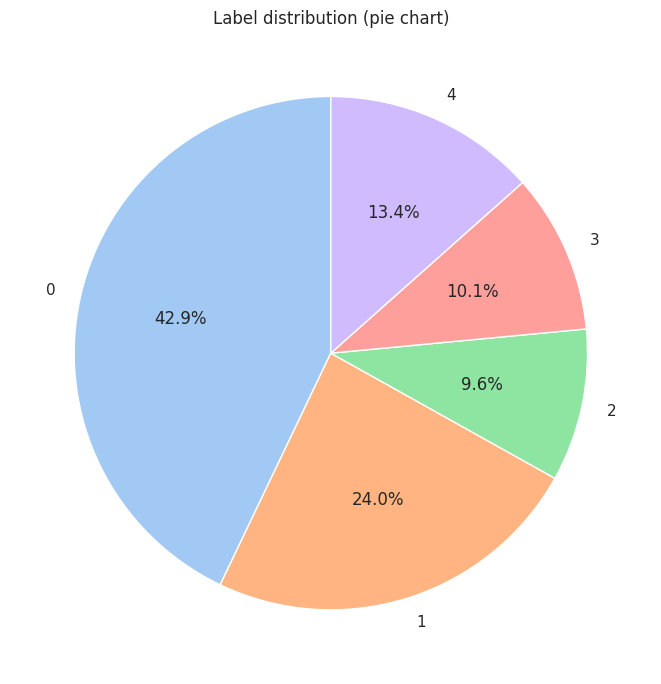

In [ ]:
label_col = "label"

label_counts = df[label_col].value_counts(dropna=False).sort_index()
label_pct = (label_counts / len(df) * 100).round(2)

label_dist_df = pd.DataFrame({
    "label": label_counts.index,
    "count": label_counts.values,
    "percentage": label_pct.values,
})

print("Label distribution (count and percentage):")
display(label_dist_df)

plt.figure(figsize=(7, 7))
colors = sns.color_palette("pastel", n_colors=len(label_counts))
wedges, texts, autotexts = plt.pie(
    label_counts.values,
    labels=label_counts.index.astype(str),
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1},
)
plt.title("Phân bổ nhãn điểm số các công thức theo query người dùng")
plt.tight_layout()
plt.show()

Phân bố nhãn liên quan cho thấy dữ liệu bị lệch lớp ở mức đáng kể. Cụ thể, nhãn **0** chiếm tỷ lệ lớn nhất (**42.9%**), tiếp theo là nhãn **1** (**24.0%**). Hai mức nhãn thấp (0--1) cộng lại chiếm **66.9%**, cho thấy phần lớn cặp query--recipe trong tập dữ liệu có mức liên quan thấp hoặc không liên quan rõ rệt.

Các nhãn cao hơn xuất hiện ít hơn (nhãn **2: 9.6%**, **3: 10.1%**, **4: 13.4%**), phản ánh đặc trưng thường gặp của bài toán retrieval/ranking: đa số ứng viên là khớp yếu, chỉ một phần nhỏ là khớp tốt.

Sự mất cân bằng này là hợp lý về mặt thực tế nhưng cần được lưu ý khi huấn luyện mô hình. Nếu không kiểm soát, mô hình có thể thiên về dự đoán nhãn thấp, từ đó làm giảm chất lượng xếp hạng ở nhóm kết quả liên quan cao. Ở các bước modeling tiếp theo, nên theo dõi sát các chỉ số xếp hạng như **NDCG/MRR/HIT** và cân nhắc các kỹ thuật xử lý mất cân bằng (ví dụ: **weighted loss**, **query-aware sampling**) khi quan sát thấy các mẫu nhãn cao bị xếp hạng thấp.

## 5. Top 10 món ăn xuất hiện nhiều nhất


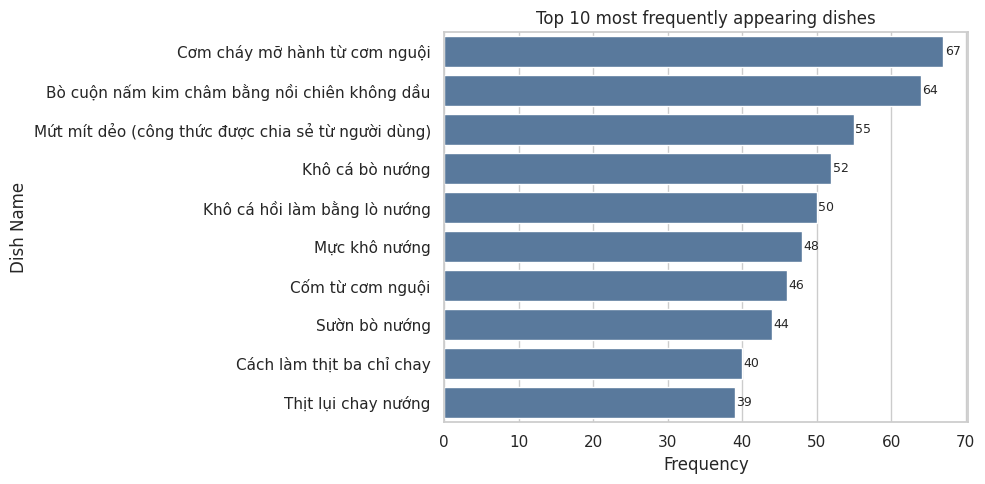

In [ ]:
name_col = "dish_name"

top10_dishes = (
    df[name_col]
    .astype(str)
    .str.strip()
    .value_counts()
    .head(10)
    .reset_index()
)
top10_dishes.columns = ["dish_name", "frequency"]

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=top10_dishes,
    x="frequency",
    y="dish_name",
    color="#4e79a7"
)

for patch in ax.patches:
    width = patch.get_width()
    y = patch.get_y() + patch.get_height() / 2
    ax.text(width + 0.2, y, f"{int(width)}", va="center", ha="left", fontsize=9)

plt.title("Top 10 các món ăn phổ biến nhất")
plt.xlabel("Tần suất")
plt.ylabel("Tên món ăn")
plt.tight_layout()
plt.show()